In [1]:
from functools import partial
from typing import Union

import chex
import jax
import jax.numpy as jnp
from flax.training.train_state import TrainState  # Useful dataclass to keep train state
from jax.tree import map as tree_map
from matplotlib import pyplot as plt
from tqdm import tqdm
import numpy as np

# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# os.environ['JAX_PLATFORMS']='cpu'
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')

from run_pinns import *


from load_metrics import load_metrics

In [23]:
num_interior = 80 * 8
num_boundary = 20 * 8
interior_points, boundary_points = generate_training_data(num_interior, num_boundary)

dims = 256


NM = ((1,1), 
      (1,2), (2,1), # sanity check
      (2,2), (3,3), (4,4))

problem_data = (interior_points, boundary_points)
def get_forcing_fxn(n, m):
    return  lambda x: (n ** 2 + m ** 2) * jnp.pi * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(m * jnp.pi * x[1])


path = "data"
n_curves = len(metrics_history_sgd)
colors = plt.cm.get_cmap('tab10', n_curves)

/var/folders/jc/hbh56n2114d44h5k85mrw9sr003gz4/T/ipykernel_32312/2361546264.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_curves)


In [22]:

metrics_history_sgd = {}

for n,m in NM:

    name = f"{path}/sgd_fx_{n}_fy_{m}"    
    try:
        metrics_history_sgd[name] = load_metrics(f"{name}.pkl")
    
    except:
        model = MLP_1D(1, dims)
        state = create_train_state(model, learning_rate=1e-3, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))
        state, metrics = train_model(state,
                                     problem_data=problem_data,
                                     forcing_function=get_forcing_fxn(n, m),
                                     num_iterations=10000,
                                     lm_schedule=None,
                                     batch_size=200,
                                     metrics_file=name
                                     )
        
        metrics_history_sgd[name] = metrics


Successfully loaded metrics from: data/sgd_fx_1_fy_1.pkl
Successfully loaded metrics from: data/sgd_fx_1_fy_2.pkl
Successfully loaded metrics from: data/sgd_fx_2_fy_1.pkl
Successfully loaded metrics from: data/sgd_fx_2_fy_2.pkl
Successfully loaded metrics from: data/sgd_fx_3_fy_3.pkl
Successfully loaded metrics from: data/sgd_fx_4_fy_4.pkl


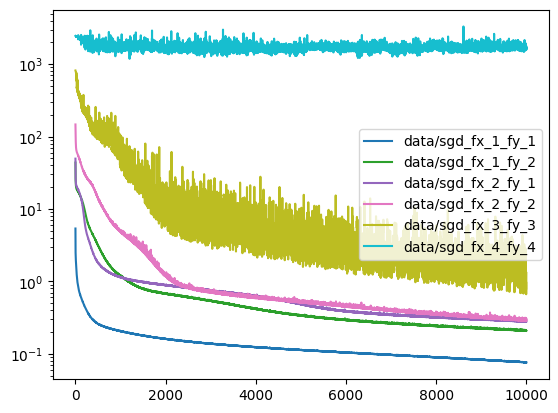

In [24]:

for i, (slvr, metrics) in enumerate(metrics_history_sgd.items()):
    plt.semilogy(np.array(metrics['train_loss']), label=slvr, color=colors(i))
plt.legend()
plt.show()


In [25]:
metrics_history_smw_lamb_1e1 = {}

lr = 2e-2
lm_info = PrecondData(
    method='smw',epoch=0, lamb=1e-1,
)

for n,m in NM:
    
    name = f"{path}/smw_fx_{n}_fy_{m}"
    
    try:
        metrics_history_smw_lamb_1e1[name] = load_metrics(f"{name}.pkl")
    
    except:
        model = MLP_1D(1, dims)
        state = create_train_state(model, learning_rate=lr, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))
        state, metrics = train_model(state,
                                     problem_data=problem_data,
                                     forcing_function=get_forcing_fxn(n, m),
                                     num_iterations=10000,
                                     lm_schedule=lm_info,
                                     batch_size=200,
                                     metrics_file=name
                                     )
    
    
        metrics_history_smw_lamb_1e1[name] = metrics

Successfully loaded metrics from: data/smw_fx_1_fy_1.pkl
Successfully loaded metrics from: data/smw_fx_1_fy_2.pkl
Successfully loaded metrics from: data/smw_fx_2_fy_1.pkl
Successfully loaded metrics from: data/smw_fx_2_fy_2.pkl
Successfully loaded metrics from: data/smw_fx_3_fy_3.pkl
Successfully loaded metrics from: data/smw_fx_4_fy_4.pkl


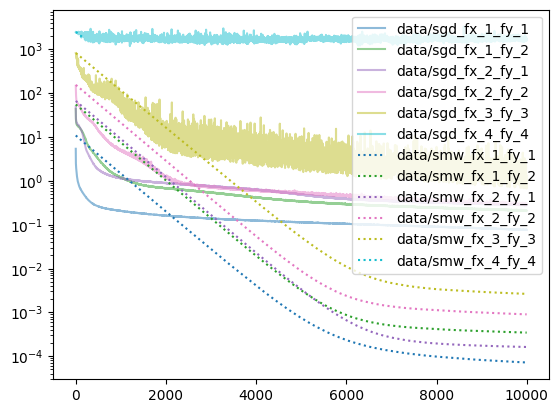

In [27]:


for i, (slvr, metrics) in enumerate(metrics_history_sgd.items()):
    plt.semilogy(np.array(metrics['train_loss']), label=slvr, linestyle='solid', color=colors(i), alpha=0.5)

for i, (slvr, metrics) in enumerate(metrics_history_smw_lamb_1e1.items()):
    plt.semilogy(np.array(metrics['train_loss']), label=slvr, linestyle='dotted', color=colors(i))
    
plt.legend()
plt.show()

In [29]:
metrics_history_smw_lamb_1e2 = {}

lr = 1e-2
lm_info = PrecondData(
    method='smw', epoch=0, lamb=1e-2,
)

for n,m in NM:
    
    name = f"{path}/smw_fx_{n}_fy_{m}"
    try:
        metrics_history_smw_lamb_1e2[name] = load_metrics(f"{name}.pkl")
    except:
        model = MLP_1D(1, dims)
        state = create_train_state(model, learning_rate=lr, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))
        state, metrics = train_model(
                                    state,
                                    problem_data=problem_data,
                                    forcing_function=get_forcing_fxn(n, m),
                                    num_iterations=2000,
                                    lm_schedule=lm_info,
                                    batch_size=100,
                                    metrics_file=name
                                )
        
        metrics_history_smw_lamb_1e2[name] = metrics


Successfully loaded metrics from: data/smw_fx_1_fy_1.pkl
Successfully loaded metrics from: data/smw_fx_1_fy_2.pkl
Successfully loaded metrics from: data/smw_fx_2_fy_1.pkl
Successfully loaded metrics from: data/smw_fx_2_fy_2.pkl
Successfully loaded metrics from: data/smw_fx_3_fy_3.pkl
Successfully loaded metrics from: data/smw_fx_4_fy_4.pkl


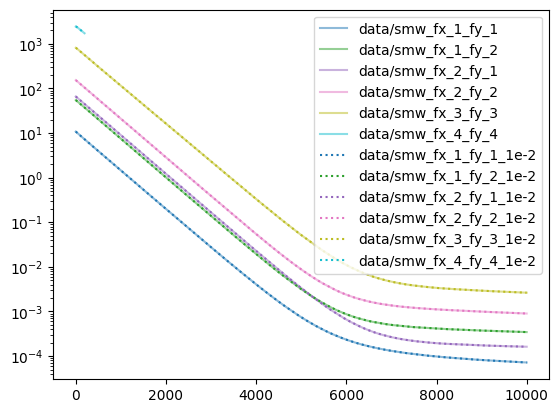

In [31]:
for i, (slvr, metrics) in enumerate(metrics_history_smw_lamb_1e1.items()):
    plt.semilogy(np.array(metrics['train_loss']), label=f"{slvr}", linestyle='solid', color=colors(i), alpha=0.5)

for i, (slvr, metrics) in enumerate(metrics_history_smw_lamb_1e2.items()):
    plt.semilogy(np.array(metrics['train_loss']), label=f"{slvr}_1e-2", linestyle='dotted', color=colors(i))
    
plt.legend()
plt.show()

In [32]:
metrics_history_gn = {}

lr = 5e-3
lm_info = PrecondData(
    method='gn-exact', epoch=0, thresh=1e-3,
)

for n,m in NM:
    name = f"{path}/gn_fx_{n}_fy_{m}"
    
    try:
        metrics_history_gn[name] = load_metrics(f"{name}.pkl")
    except:
        model = MLP_1D(1, dims)
        state = create_train_state(model, learning_rate=lr, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))
        
        state, metrics = train_model(
                                    state,
                                    problem_data=problem_data,
                                    forcing_function=get_forcing_fxn(n, m),
                                    num_iterations=5000,
                                    lm_schedule=lm_info,
                                    batch_size=100,
                                    metrics_file=name
                                )
        
        metrics_history_gn[name] = metrics


Successfully loaded metrics from: data/gn_fx_1_fy_1.pkl
Successfully loaded metrics from: data/gn_fx_1_fy_2.pkl
Successfully loaded metrics from: data/gn_fx_2_fy_1.pkl
Successfully loaded metrics from: data/gn_fx_2_fy_2.pkl
Successfully loaded metrics from: data/gn_fx_3_fy_3.pkl
Successfully loaded metrics from: data/gn_fx_4_fy_4.pkl


5000
500
5000
5000
500
500


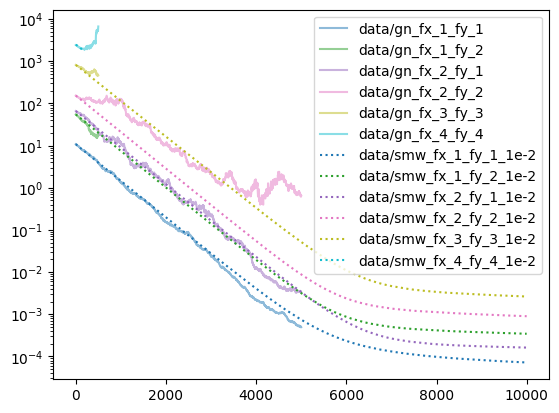

In [52]:
for i, (slvr, metrics) in enumerate(metrics_history_gn.items()):
    arr = np.array(metrics['train_loss'])

    arr = arr[:500] if np.isnan(np.min(arr)) else arr

    print(len(arr))
    plt.semilogy(arr, label=f"{slvr}", linestyle='solid', color=colors(i), alpha=0.5)

for i, (slvr, metrics) in enumerate(metrics_history_smw_lamb_1e2.items()):
    plt.semilogy(np.array(metrics['train_loss']), label=f"{slvr}_1e-2", linestyle='dotted', color=colors(i))
    
plt.legend()
plt.show()

In [42]:
arr[10] > arr[0] 

np.False_